In [1]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
from random import sample
from scipy import stats
import emcee
import time
import math
import corner
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc


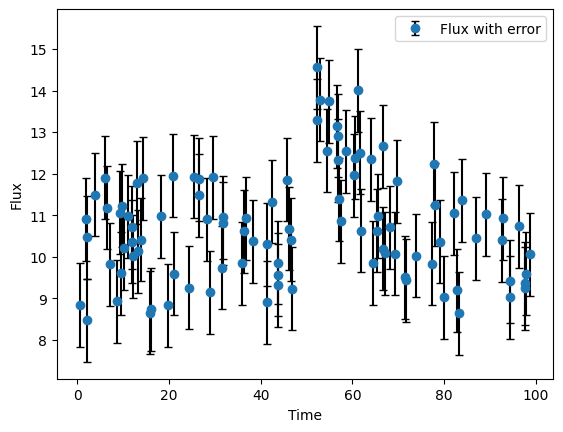

In [2]:
data=np.load("Transient.npy")
times=data[:,0]
flux=data[:,1]
err=data[:,2]
plt.errorbar(times, flux, yerr=err, fmt='o', ecolor='black', capsize=3, label='Flux with error')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.legend()
plt.show()

In [5]:
def model2(x):
    return x[1]+x[2]*np.exp(-(times-x[0])**2/(2*(np.exp(x[3]))**2)) 
   
def LogLikelihood2(x):
   return  -0.5*np.sum(((flux-model2(x))/err)**2+np.log(2*np.pi*err**2))

def prior_t0(x):
   return x[0]*100

def prior_A(x):
    return x[2]*50
    
def prior_b(x):
    return x[1]*50
    
def prior_lnsigma(x):
    return 5*(2*x[3]-1)
   
def prior2(x):
    return [prior_t0(x),prior_b(x),prior_A(x),prior_lnsigma(x)]

In [6]:
sampler = dynesty.NestedSampler(LogLikelihood2, prior2, 4)
sampler.run_nested()
results = sampler.results

iter: 4045 | bound: 57 | nc: 29 | ncall: 60299 | eff(%):  6.708 | loglstar:   -inf < -178.720 <    inf | logz: -185.571 +/-  0.110 | dlogz: 29.235 >  0.509                                           /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 4103 | bound: 69 | nc: 331 | ncall: 69077 | eff(%):  5.940 | loglstar:   -inf < -178.400 <    inf | logz: -185.535 +/-  0.110 | dlogz: 29.083 >  0.509                                          /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/dynesty/bounding.py:6